In [77]:
import os
import json
import numpy as np
import pandas as pd
from obspy import UTCDateTime
from matplotlib import pyplot as plt
from cartopy import crs as ccrs


# Read station file as pandas dataframe

In [58]:
db_dir = '../data'
station_file = os.path.join(db_dir, 'station.txt')

dtype = {'network':'str', 'station':'str', 'longitude':'float', 'latitude':'float', 'elevation':'float'}
df_station = pd.read_csv(station_file, dtype=dtype, comment='#')

df_station.head(5)

,network,station,longitude,latitude,elevation
0,YW,1001,-97.740955,36.622297,322.2
1,YW,1002,-97.739831,36.622301,322.3
2,YW,1003,-97.738707,36.622319,322.4
3,YW,1004,-97.737583,36.622297,322.7
4,YW,1005,-97.736458,36.622309,322.7


# Subnetworks

In [78]:
#--- subnetworks file
rs_file = 'rs_list.json'

rs_list = json.load(open(rs_file, 'r'))

# Read analyst catalog as pandas dataframe

In [60]:
analyst_catalog_file = 'analyst_catalog.csv'

df_anl_cat = pd.read_csv(analyst_catalog_file)

df_anl_cat .head(5)

,time,longitude,latitude,depth,magnitude
0,2016-07-11 01:22:45.776,-97.7139,36.6471,8.3,0.3
1,2016-07-11 04:20:57.929,-97.7574,36.6287,4.4,-0.2
2,2016-07-11 05:16:38.187,-97.6924,36.6053,3.4,0.2
3,2016-07-11 05:26:50.274,-97.6870,36.6160,2.5,0.9
4,2016-07-11 05:27:27.181,-97.6919,36.6052,3.5,-0.1


#### Selected event

In [73]:
i_ = 6 # row number

row = df_anl_cat.loc[i_]

evt0 = UTCDateTime(row.time)    # Event origin time
evlo = row.longitude            # Event longitude (deg)
evla = row.latitude             # Event latitude (deg)
evdp = row.depth                # Event depth (km)
mag = row.magnitude             # Event magnitude

# Plot map

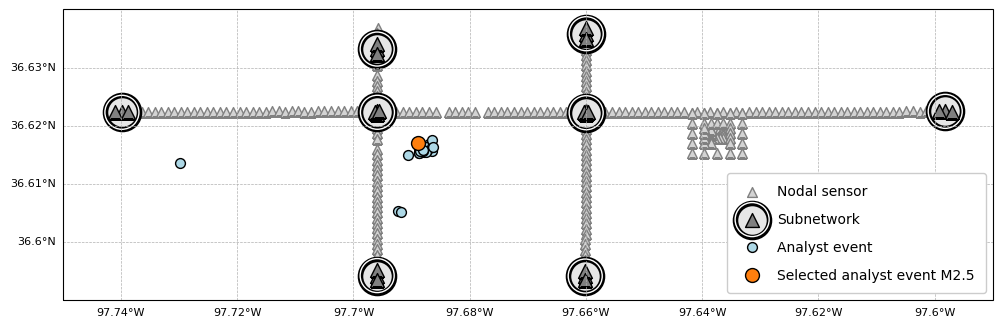

In [108]:
xmin, xmax = -97.75, -97.59
ymin, ymax = 36.59, 36.64

plt.close('all')

%matplotlib inline

fig =  plt.figure(figsize=(12,6))
projection = ccrs.PlateCarree()

ax = fig.add_subplot(projection=projection)
gl = ax.gridlines(ls='--', lw=0.5)
gl.bottom_labels = True
gl.left_labels = True
gl.xlabel_style = {'fontsize':8}
gl.ylabel_style = {'fontsize':8}

#---- plot stations
h_nodal = ax.scatter(df_station.longitude, df_station.latitude, marker='^', ec='grey', fc='lightgrey', s=50)

#--- plot subnetworks
stlo_list = []
stla_list = []
for rs in rs_list:
    h_sub_c1 = ax.scatter(rs['reference_longitude'], rs['reference_latitude'], s=600, ec='k', fc=(0.9,0.9,0.9), lw=4.0)
    h_sub_c2 = ax.scatter(rs['reference_longitude'], rs['reference_latitude'], s=600, ec='w', fc='none', lw=1.0)
    
    stlo_list.append(rs['reference_longitude'])
    stla_list.append(rs['reference_latitude'])
    stlo_list += rs['secondaries_longitude']
    stla_list += rs['secondaries_latitude']
    
h_sub = ax.scatter(stlo_list, stla_list, marker='^', ec='k', fc='grey', s=100)

#---- plot analyst events
h_evt = ax.scatter(df_anl_cat.longitude, df_anl_cat.latitude, marker='o', ec='k', fc='lightblue', s=50)

#---- plot selected analyst events
h_evt_sel = ax.scatter(evlo, evla, marker='o', ec='k', fc='tab:orange', s=100)

#--- set axes limit
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

#--- legend
handles = [h_nodal, (h_sub_c1, h_sub_c2, h_sub), h_evt, h_evt_sel]
labels = ['Nodal sensor', 'Subnetwork', 'Analyst event', f'Selected analyst event M{mag}']

ax.legend(handles, labels, loc=4, framealpha=1.0, labelspacing = 1.0, borderpad=0.8);
